📦 Đang tải dữ liệu...
✅ Đã tải 1794 luật và bảng giá sản phẩm.
✅ Đã tính xong các chỉ số trọng số (Economic Score & Potential Revenue).

📊 Phân bố các nhóm luật:
Category
Nhóm 3: Bình Dân (Low Value/Lift)             1256
Nhóm 2: Mỏ Vàng Ẩn (Low Supp - High Value)     450
Nhóm 1: Ngôi Sao (High Supp - High Value)       88
Name: count, dtype: int64


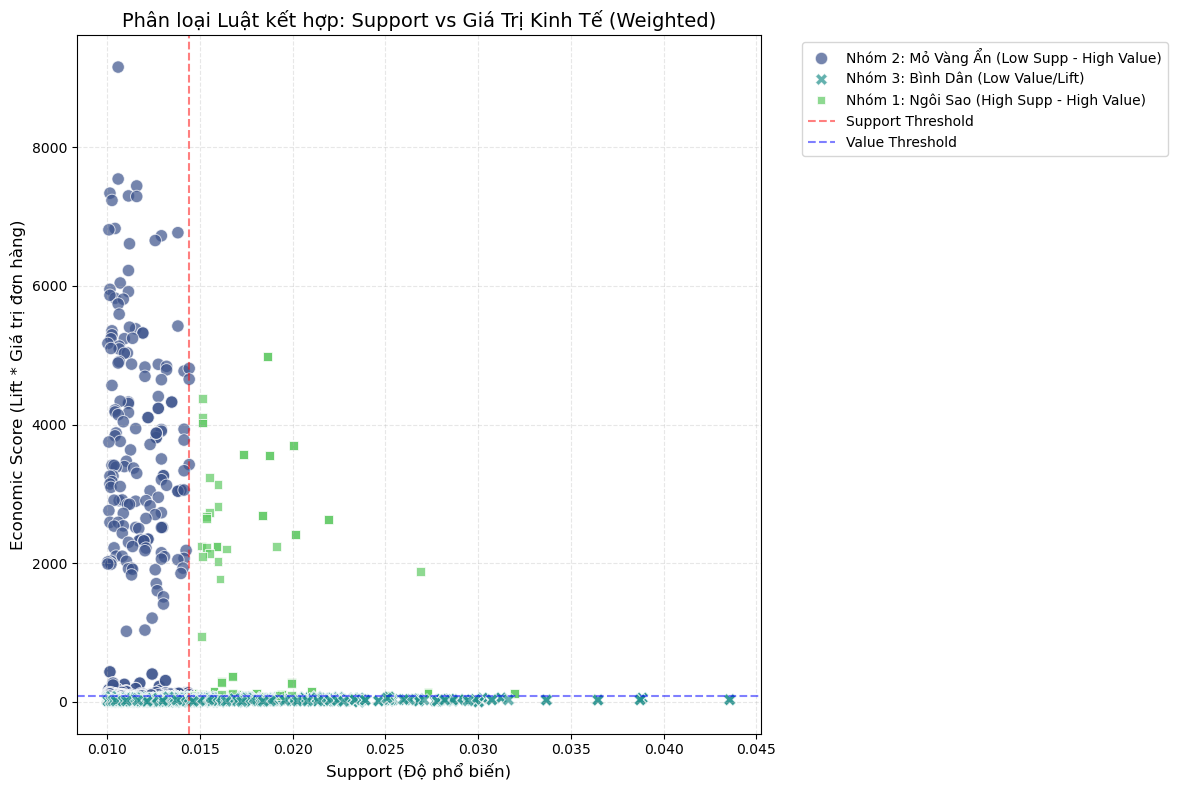

------------------------------------------------------------
🚀 ĐỀ XUẤT CHIẾN LƯỢC KINH DOANH (CHỦ ĐỀ 3)
------------------------------------------------------------

💎 NHÓM 1: NGÔI SAO (Top 3 ví dụ)
>> Đặc điểm: Bán chạy, giá trị đơn hàng cao, mối liên hệ mạnh.
>> Chiến lược: Bundle giảm giá nhẹ, trưng bày vị trí đẹp nhất (Homepage/Kệ chính).
  - Nếu mua [DOTCOM POSTAGE] -> Gợi ý [SUKI  SHOULDER BAG] (Score: 4982.0)
  - Nếu mua [SUKI  SHOULDER BAG] -> Gợi ý [DOTCOM POSTAGE] (Score: 4982.0)
  - Nếu mua [JUMBO BAG RED RETROSPOT, JUMBO BAG WOODLAND ANIMALS] -> Gợi ý [DOTCOM POSTAGE] (Score: 4377.2)

💰 NHÓM 2: MỎ VÀNG ẨN (Top 3 ví dụ)
>> Đặc điểm: Ít người mua, nhưng ai mua là đơn hàng to (VIP/High-ticket).
>> Chiến lược: Cross-sell cá nhân hóa (Email marketing cho khách VIP), không giảm giá đại trà.
  - Nếu mua [DOTCOM POSTAGE, SKULL SHOULDER BAG] -> Gợi ý [SUKI  SHOULDER BAG] (Score: 9154.5)
  - Nếu mua [DOTCOM POSTAGE, SUKI  SHOULDER BAG] -> Gợi ý [SKULL SHOULDER BAG] (Score: 7540.9)
  

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- CẤU HÌNH ---
# Đường dẫn file (điều chỉnh nếu cần)
DATA_PATH = "../data/processed/cleaned_uk_data.csv"
RULES_PATH = "../data/processed/rules_fpgrowth_filtered.csv" 
# Nếu bạn chưa có file filtered, hãy dùng file kết quả từ fp_growth_modelling

# 1. TẢI DỮ LIỆU VÀ CHUẨN BỊ GIÁ
print("📦 Đang tải dữ liệu...")
try:
    df_prices = pd.read_csv(DATA_PATH, dtype={'InvoiceNo': str})
    # Tính giá trung bình sản phẩm (UnitPrice)
    product_prices = df_prices.groupby('Description')['UnitPrice'].mean().to_dict()
    
    # Tải tập luật đã chạy từ FP-Growth
    rules = pd.read_csv(RULES_PATH)
    print(f"✅ Đã tải {len(rules)} luật và bảng giá sản phẩm.")
except Exception as e:
    print(f"❌ Lỗi: {e}")
    print("Vui lòng đảm bảo bạn đã chạy FP-Growth và lưu file rules_fpgrowth_filtered.csv")

# 2. TÍNH TOÁN TRỌNG SỐ (WEIGHTED METRICS)
# Sử dụng logic từ file weighted_analysis.ipynb: Tính tổng giá trị gói hàng trong luật
def calculate_basket_value(itemset_str):
    try:
        # Xử lý chuỗi frozenset thành list
        clean_str = itemset_str.replace("frozenset({", "").replace("})", "").replace("'", "")
        items = [x.strip() for x in clean_str.split(", ")]
        total_price = sum([product_prices.get(item, 0) for item in items])
        return total_price
    except:
        return 0

# Tính giá trị
rules['antecedent_value'] = rules['antecedents'].apply(calculate_basket_value)
rules['consequent_value'] = rules['consequents'].apply(calculate_basket_value)
rules['total_basket_value'] = rules['antecedent_value'] + rules['consequent_value']

# --- ĐỊNH NGHĨA CHỈ SỐ CHO CHỦ ĐỀ 3 ---
# 1. Economic Score (Giá trị kinh tế) = Lift * Tổng giá trị gói hàng
# Đây là chỉ số đại diện cho "Weighted Lift" theo cách đơn giản hóa (Level 5.3.1.3 trong Lab)
rules['economic_score'] = rules['lift'] * rules['total_basket_value']

# 2. Potential Revenue (Doanh thu tiềm năng) = Support * Tổng giá trị
# Đại diện cho việc luật này mang lại bao nhiêu tiền trên tổng thể
rules['potential_revenue_score'] = rules['support'] * rules['total_basket_value']

print("✅ Đã tính xong các chỉ số trọng số (Economic Score & Potential Revenue).")

# 3. PHÂN LOẠI LUẬT (SEGMENTATION) [Quan trọng cho Chủ đề 3]

# Thiết lập các ngưỡng (Thresholds) - Có thể điều chỉnh dựa trên dữ liệu thực tế
# Dùng quantile để tự động chọn ngưỡng (ví dụ: top 20% là cao)
sup_threshold = rules['support'].quantile(0.70)      # Top 30% support cao
lift_threshold = rules['lift'].quantile(0.70)        # Top 30% lift cao
value_threshold = rules['economic_score'].quantile(0.70) # Top 30% giá trị cao

def classify_rule(row):
    # Nhóm 1: Stars (Phổ biến & Giá trị cao)
    if (row['support'] > sup_threshold) and (row['economic_score'] > value_threshold):
        return "Nhóm 1: Ngôi Sao (High Supp - High Value)"
    
    # Nhóm 2: Hidden Gems (Hiếm nhưng đắt tiền/lời to)
    elif (row['support'] <= sup_threshold) and (row['economic_score'] > value_threshold):
        return "Nhóm 2: Mỏ Vàng Ẩn (Low Supp - High Value)"
    
    # Nhóm 3: Commodity/Obvious (Tự tin cao nhưng giá trị/lift thấp)
    # Lưu ý: Lift thấp (gần 1) nghĩa là không ngẫu nhiên nhưng không quá đặc sắc
    elif (row['lift'] < lift_threshold) or (row['economic_score'] < value_threshold):
        return "Nhóm 3: Bình Dân (Low Value/Lift)"
    
    else:
        return "Nhóm 4: Trung Bình (Others)"

rules['Category'] = rules.apply(classify_rule, axis=1)

# Thống kê số lượng từng nhóm
print("\n📊 Phân bố các nhóm luật:")
print(rules['Category'].value_counts())

# 4. TRỰC QUAN HÓA (VISUALIZATION)
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=rules,
    x='support',
    y='economic_score',
    hue='Category',
    style='Category',
    s=80,
    alpha=0.7,
    palette='viridis' # Hoặc 'deep'
)

# Vẽ đường phân chia ngưỡng để dễ nhìn
plt.axvline(x=sup_threshold, color='red', linestyle='--', alpha=0.5, label='Support Threshold')
plt.axhline(y=value_threshold, color='blue', linestyle='--', alpha=0.5, label='Value Threshold')

plt.title('Phân loại Luật kết hợp: Support vs Giá Trị Kinh Tế (Weighted)', fontsize=14)
plt.xlabel('Support (Độ phổ biến)', fontsize=12)
plt.ylabel('Economic Score (Lift * Giá trị đơn hàng)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. XUẤT INSIGHT KINH DOANH
print("-" * 60)
print("🚀 ĐỀ XUẤT CHIẾN LƯỢC KINH DOANH (CHỦ ĐỀ 3)")
print("-" * 60)

# --- Phân tích Nhóm 1 ---
group1 = rules[rules['Category'] == "Nhóm 1: Ngôi Sao (High Supp - High Value)"].sort_values('economic_score', ascending=False).head(3)
print(f"\n💎 NHÓM 1: NGÔI SAO (Top {len(group1)} ví dụ)")
print(">> Đặc điểm: Bán chạy, giá trị đơn hàng cao, mối liên hệ mạnh.")
print(">> Chiến lược: Bundle giảm giá nhẹ, trưng bày vị trí đẹp nhất (Homepage/Kệ chính).")
for idx, row in group1.iterrows():
    print(f"  - Nếu mua [{row['antecedents_str']}] -> Gợi ý [{row['consequents_str']}] (Score: {row['economic_score']:.1f})")

# --- Phân tích Nhóm 2 ---
group2 = rules[rules['Category'] == "Nhóm 2: Mỏ Vàng Ẩn (Low Supp - High Value)"].sort_values('economic_score', ascending=False).head(3)
print(f"\n💰 NHÓM 2: MỎ VÀNG ẨN (Top {len(group2)} ví dụ)")
print(">> Đặc điểm: Ít người mua, nhưng ai mua là đơn hàng to (VIP/High-ticket).")
print(">> Chiến lược: Cross-sell cá nhân hóa (Email marketing cho khách VIP), không giảm giá đại trà.")
for idx, row in group2.iterrows():
    print(f"  - Nếu mua [{row['antecedents_str']}] -> Gợi ý [{row['consequents_str']}] (Score: {row['economic_score']:.1f})")

# --- Phân tích Nhóm 3 ---
group3 = rules[rules['Category'] == "Nhóm 3: Bình Dân (Low Value/Lift)"].sort_values('confidence', ascending=False).head(3)
print(f"\n🛒 NHÓM 3: BÌNH DÂN (Top {len(group3)} ví dụ)")
print(">> Đặc điểm: Giá trị thấp hoặc mối liên hệ không quá đặc biệt (Lift thấp).")
print(">> Chiến lược: Dùng làm sản phẩm mồi (Traffic builder), đặt cạnh quầy thu ngân để mua kèm (Impulse buying).")
for idx, row in group3.iterrows():
    print(f"  - Nếu mua [{row['antecedents_str']}] -> Gợi ý [{row['consequents_str']}] (Conf: {row['confidence']:.2f})")